## 02_bar_chart.ipynb

In [1]:
import pandas as pd
import sqlite3

In [2]:
db_path = "../data/checking-logs.sqlite"
conn = sqlite3.connect(db_path)

## Analyze only the users, not the admins.

In [3]:
query = """
    SELECT date(timestamp) AS date,
    CASE
        WHEN time(timestamp) BETWEEN '00:00:00' AND '03:59:59' THEN 'night'
        WHEN time(timestamp) BETWEEN '04:00:00' AND '09:59:59' THEN 'morning'
        WHEN time(timestamp) BETWEEN '10:00:00' AND '16:59:59' THEN 'afternoon'
    ELSE 'evening'
    END AS daytime,
    count (*) AS commits
    FROM checker
    WHERE uid like 'user_%'
    GROUP BY date,daytime
    """

commits = pd.read_sql(query, conn)

In [4]:
data = commits.pivot(index='date', columns = 'daytime', values = 'commits').fillna(0)
data = data[['night', 'morning', 'afternoon', 'evening']]
data

daytime,night,morning,afternoon,evening
date,,,,
2020-04-17,0.0,13.0,10.0,0.0
2020-04-18,0.0,1.0,33.0,35.0
2020-04-19,2.0,4.0,16.0,11.0
2020-04-20,0.0,0.0,12.0,13.0
2020-04-21,0.0,0.0,0.0,25.0
2020-04-22,0.0,0.0,4.0,24.0
2020-04-23,2.0,6.0,15.0,20.0
2020-04-24,0.0,0.0,4.0,12.0
2020-04-25,1.0,21.0,33.0,49.0


## Create a graph

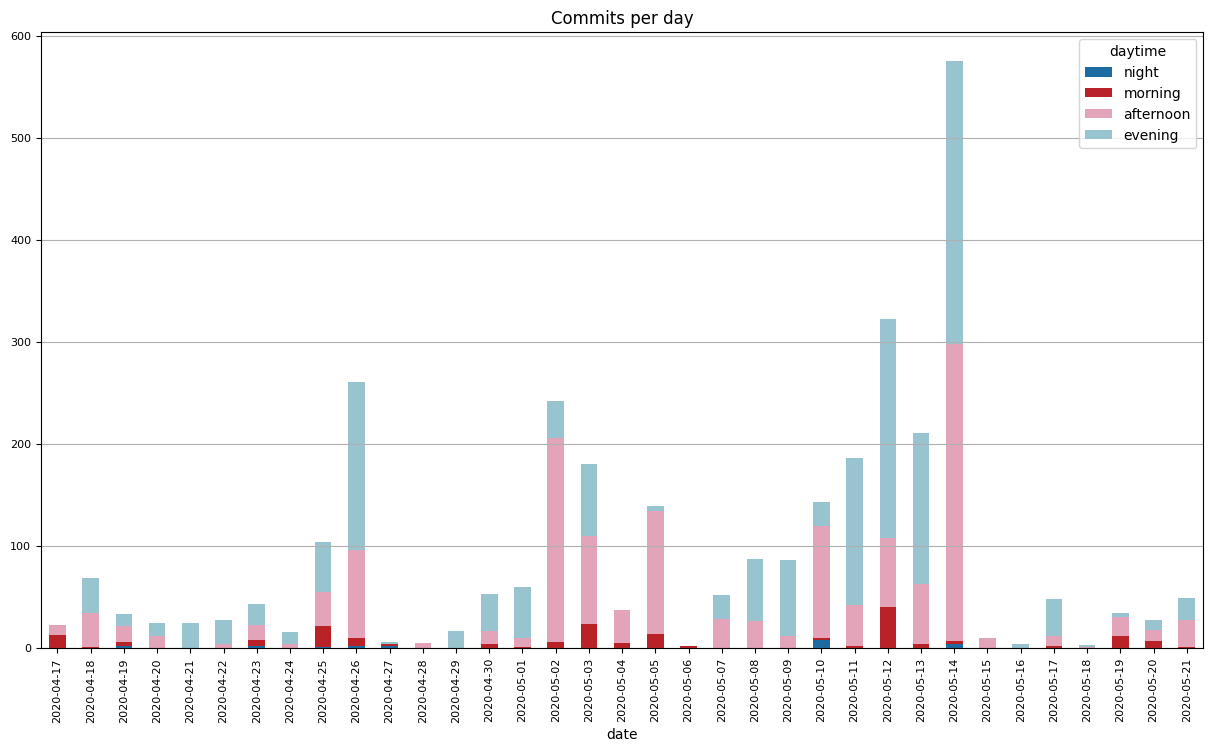

In [5]:
colors = {
    'night': '#1E6BA1',
    'morning': '#B92227',
    'afternoon': '#E3A4BA',
    'evening': '#98C4CF',
}

plot = data.plot(
    fontsize=8,
    figsize=(15,8),
    title='Commits per day',
    rot=90,
    kind='bar',
    stacked=True,
    color=colors
)
plot.yaxis.grid(True)

In [6]:
conn.close()

## When do our users usually commit to the labs: in the night, morning, afternoon, or evening?

In [7]:
answer = data.sum().sort_values(ascending=False).head(2)
answer

daytime
evening      1611.0
afternoon    1391.0
dtype: float64

## Which day has the most number of commits? And at the same time, is the number of commits higher in the evening than in the afternoon?

In [8]:
daily_commits = data.sum(axis=1)

answer_date = (
    daily_commits
    .loc[data['evening'] > data['afternoon']]
    .idxmax()
)
answer_date

'2020-05-12'